In [ ]:
# Lightweight path setup for local Jupyter, VS Code, or Colab runs.
# It keeps the notebook runnable whether you start it from this folder or the repo root.
from pathlib import Path
import os

FOLDER_NAME = '30-Vision-Transformers'
NOTEBOOK_NAME = 'Project03_MaskedAutoEncoder_CIFAR10.ipynb'

candidates = [
    Path.cwd(),
    Path.cwd() / FOLDER_NAME,
    Path.cwd() / "10-deep_learning" / FOLDER_NAME,
    Path.cwd().parent / FOLDER_NAME,
    Path.cwd().parent / "10-deep_learning" / FOLDER_NAME,
]

for candidate in candidates:
    if (candidate / NOTEBOOK_NAME).exists():
        os.chdir(candidate)
        break

print("Working directory:", Path.cwd().resolve())


In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q transformers datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 16.1.0 which is incompatible.
google-colab 1.0.0 requires requests==2.31.0, but you have requests 2.32.3 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 16.1.0 which is incompatible.


# Import dataset

In [3]:
from datasets import load_dataset
train_ds, test_ds = load_dataset('cifar10', split=['train[:10]', 'test[:10]'])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [4]:
train_ds

Dataset({
    features: ['img', 'label'],
    num_rows: 10
})

In [5]:
test_ds

Dataset({
    features: ['img', 'label'],
    num_rows: 10
})

In [6]:
data = train_ds

In [7]:
data


Dataset({
    features: ['img', 'label'],
    num_rows: 10
})

In [8]:
images = data['img']

In [9]:
images

[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32>]

In [ ]:
type(images)

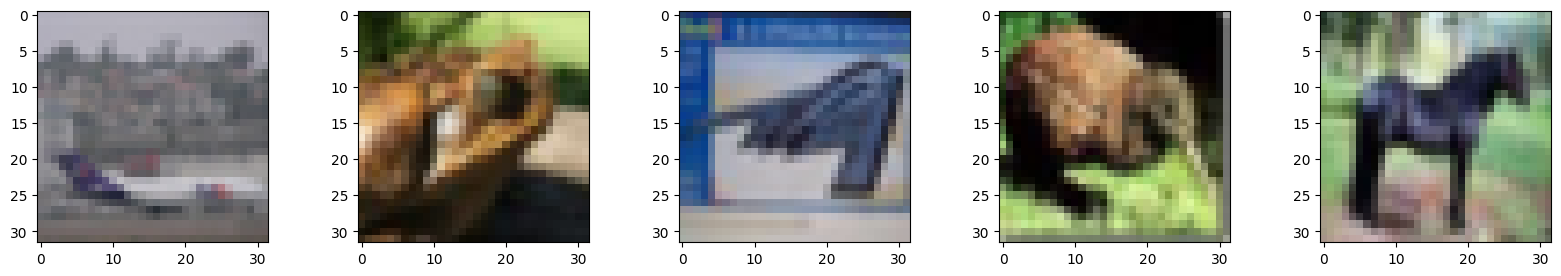

In [10]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(1,5,figsize=(20,3))

for i in range(5):
  axs[i].imshow(images[i])

plt.show()

# Import Feature Extractor

In [11]:
from transformers import ViTFeatureExtractor

feature_extractor = ViTFeatureExtractor.from_pretrained("facebook/vit-mae-base")


preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [12]:
feature_extractor

ViTFeatureExtractor {
  "_valid_processor_keys": [
    "images",
    "do_resize",
    "size",
    "resample",
    "do_rescale",
    "rescale_factor",
    "do_normalize",
    "image_mean",
    "image_std",
    "return_tensors",
    "data_format",
    "input_data_format"
  ],
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ViTFeatureExtractor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

# Get the pixel values of the images

In [13]:
pixel_values = feature_extractor(images, return_tensors="pt").pixel_values


In [14]:
pixel_values.shape

torch.Size([10, 3, 224, 224])

# Import the model

In [15]:
from transformers import ViTMAEForPreTraining

model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

model

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

ViTMAEForPreTraining(
  (vit): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (encoder): ViTMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTMAELayer(
          (attention): ViTMAESdpaAttention(
            (attention): ViTMAESdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTMAEIntermediate(
            (dense): Linear(in_features=768, out_features=

# Import visualize function to see the performance of the Masked Autoencoder

In [18]:
from visualization import visualize

# Apply visualize function

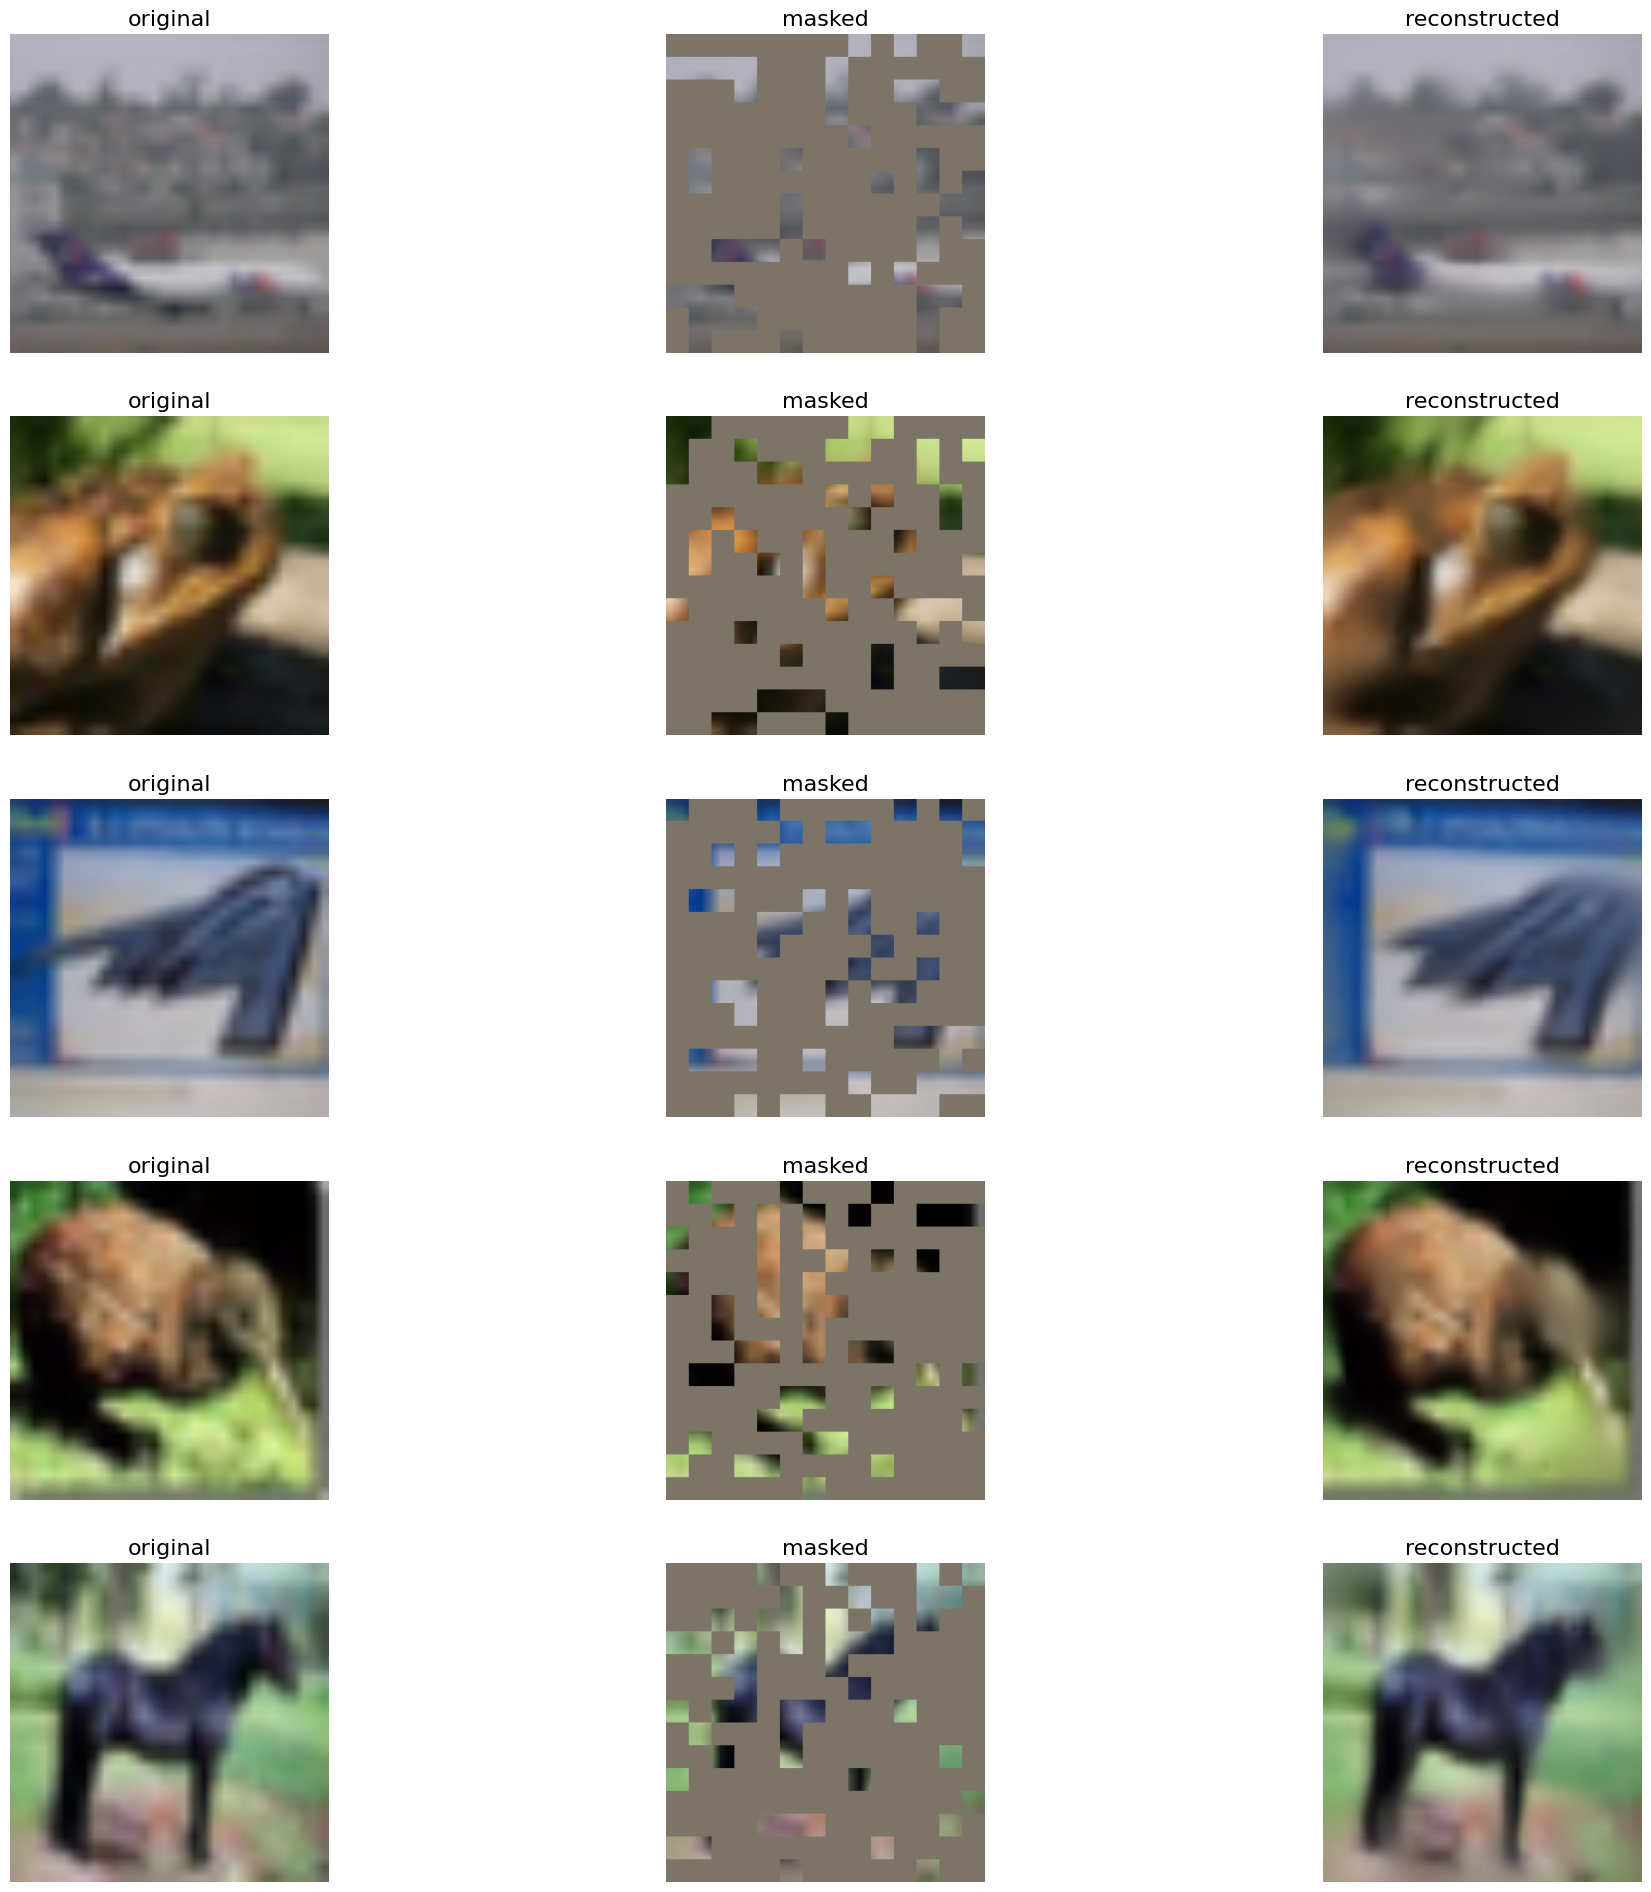

In [19]:
visualize(pixel_values, model)